# Clustering: Cardiovascular severity
Clustering to identify patients with different levels of cardiac impairment

Before clustering, we import the dependency libraries: 

In [24]:
!pip install pandas scikit-learn

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from collections import Counter
from pathlib import Path

And load the patient profile dataset 

In [26]:
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1]  / "1" / "Features" 
PATIENT_PROFILES_NAME = "patient_profiles.csv"

df = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

## Feature selection for  cardiovascular severity clustering

We take from patient profiles features all those which rely on cardiovascular severity

In [27]:
# Extract data subset
df_severity = df.copy()

In [28]:
# Handle missing values
df_severity_clean = df_severity.dropna()
print(f"\nUsable patients: {len(df_severity_clean)} / {len(df_severity)}")


Usable patients: 4694 / 4694


In [29]:
# Prepare data for clustering
X_severity = df_severity_clean


## Data normalization

In [30]:
X_severity.head()

,subject_id,valvular_disease_score,cardiac_remodeling_score,glu_var,exam_abnormality_score,respiratory_distress_score,hemodynamic_instability_score,glu_abnormal_ratio,cl_max,na_abnormal_ratio,...,na_max,creat_abnormal_ratio,creat_max,k_min,k_max,perc_invalid,total_tests,total_procedures,procedures_days_span,oxygen_saturation
0,10000980,3.0,2.0,3.420,2.0,1.946,0.000,0.678,112.0,0.202,...,146.0,1.000,1.194,4.2,1.705,0.398,9.141,2.079,0.000,0.693
1,10002013,1.8,1.6,2.848,2.0,0.000,0.693,1.000,100.0,0.000,...,136.0,0.000,0.693,3.2,1.526,0.347,3.912,1.099,0.000,1.792
2,10002155,1.7,2.4,2.421,2.0,0.000,0.000,0.688,107.0,0.272,...,143.0,0.188,0.788,4.2,1.887,0.330,5.900,2.197,2.708,1.711
3,10004457,0.0,0.0,1.718,1.0,0.693,0.000,0.000,105.0,0.000,...,143.0,0.000,0.693,5.1,1.808,0.250,3.219,0.000,0.000,1.386
4,10007058,3.0,2.0,2.103,1.0,0.000,0.000,0.800,107.0,0.000,...,141.0,0.000,0.693,3.5,1.629,0.319,4.913,1.099,0.000,1.099


In [31]:
binary_cols = []
continuous_cols = []

for col in X_severity.columns:
    unique_vals = X_severity[col].nunique()
    if unique_vals <= 2:
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"\nBinary features: {len(binary_cols)}")
print(binary_cols[:10])
print(f"\nContinuous features: {len(continuous_cols)}")
print(continuous_cols[:10])



Binary features: 0
[]

Continuous features: 22
['subject_id', 'valvular_disease_score', 'cardiac_remodeling_score', 'glu_var', 'exam_abnormality_score', 'respiratory_distress_score', 'hemodynamic_instability_score', 'glu_abnormal_ratio', 'cl_max', 'na_abnormal_ratio']


We use `RobustScaler` from sklearn to normalize contnuous features (Z-score normalization)

In [32]:
scaler = StandardScaler()
X_severity_normalized = scaler.fit_transform(X_severity)
X_severity_normalized = pd.DataFrame(
    X_severity_normalized, 
    columns=df_severity_clean.columns, 
    index=df_severity_clean.index
)


In [33]:
X_severity_normalized.head()

,subject_id,valvular_disease_score,cardiac_remodeling_score,glu_var,exam_abnormality_score,respiratory_distress_score,hemodynamic_instability_score,glu_abnormal_ratio,cl_max,na_abnormal_ratio,...,na_max,creat_abnormal_ratio,creat_max,k_min,k_max,perc_invalid,total_tests,total_procedures,procedures_days_span,oxygen_saturation
0,-1.760781,0.872352,-0.240173,0.528216,-0.182461,2.363787,-0.272548,0.059530,1.608794,0.902255,...,1.383507,1.387606,0.703738,1.113366,-0.274554,0.534678,1.892865,1.033527,-0.455299,-1.725337
1,-1.760447,-0.234556,-0.481553,-0.113788,-0.182461,-1.178931,2.339862,1.004218,-1.027973,-0.457076,...,-1.504157,-0.884280,-0.581841,-1.274416,-1.921745,0.127859,-0.721173,-0.004116,-0.455299,0.669704
2,-1.760401,-0.326798,0.001208,-0.593047,-0.182461,-1.178931,-0.272548,0.088868,0.510141,1.373310,...,0.517208,-0.457165,-0.338069,1.113366,1.400243,-0.007747,0.272651,1.158468,3.241574,0.493182
3,-1.759656,-1.894916,-1.447077,-1.382084,-1.158499,0.082684,-0.272548,-1.929595,0.070680,-0.457076,...,0.517208,-0.884280,-0.581841,3.262370,0.673271,-0.645895,-1.067612,-1.167759,-0.455299,-0.215088
4,-1.758814,0.872352,-0.240173,-0.949965,-1.158499,-1.178931,-0.272548,0.417455,0.510141,-0.457076,...,-0.060325,-0.884280,-0.581841,-0.558082,-0.973920,-0.095493,-0.220761,-0.004116,-0.455299,-0.840544


## K-means clustering 

In [34]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_severity_normalized)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_severity_normalized, kmeans.labels_))


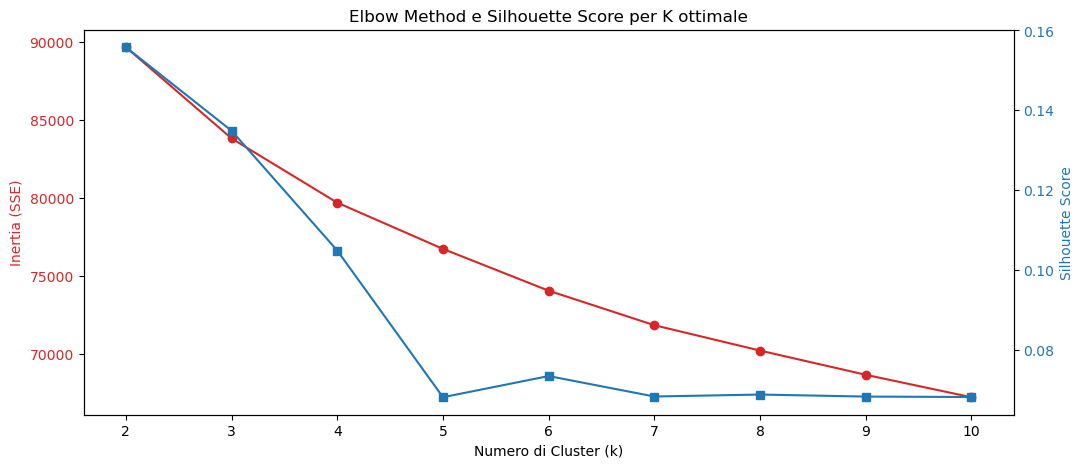

In [35]:
# Plot Elbow Method e Silhouette
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:red'
ax1.set_xlabel('Numero di Cluster (k)')
ax1.set_ylabel('Inertia (SSE)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, silhouette_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method e Silhouette Score per K ottimale')
plt.show()

In [36]:
optimal_k = 2

### Training with optimal K

In [37]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_final.fit_predict(X_severity_normalized)

In [38]:
# Add labels to dataframe
df_severity_clean['cluster'] = cluster_labels

### Clusters distribution and characterization

In [39]:
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print("\nCluster sizes:")
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(cluster_labels)) * 100
    print(f"  Cluster {cluster_id}: {count:4d} patients ({percentage:5.1f}%)")


Cluster sizes:
  Cluster 0: 1772 patients ( 37.8%)
  Cluster 1: 2922 patients ( 62.2%)


In [40]:
df_severity_clean['cluster'] = kmeans.labels_
profile = df_severity_clean.groupby('cluster').mean()
print(profile.T) 

cluster                                   0             1             2  \
subject_id                     1.461767e+07  1.509930e+07  1.536009e+07   
valvular_disease_score         2.484807e+00  2.363661e+00  6.438316e-01   
cardiac_remodeling_score       3.083811e+00  2.880055e+00  5.174165e-01   
glu_var                        2.594395e+00  3.423880e+00  3.025000e+00   
exam_abnormality_score         1.657783e+00  2.229508e+00  2.025980e+00   
respiratory_distress_score     3.674072e-01  5.943060e-01  5.026792e-01   
hemodynamic_instability_score  8.630137e-03  3.786885e-03  2.313643e-02   
glu_abnormal_ratio             8.004932e-01  7.437077e-01  7.902264e-01   
cl_max                         1.051572e+02  1.083907e+02  1.051145e+02   
na_abnormal_ratio              1.426027e-02  9.037978e-02  2.747605e-02   
cl_abnormal_ratio              4.136115e-02  1.502978e-01  5.685486e-02   
cl_min                         1.017885e+02  9.714754e+01  1.005238e+02   
na_max                   

#### PCA visualization

In [41]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_severity_normalized)


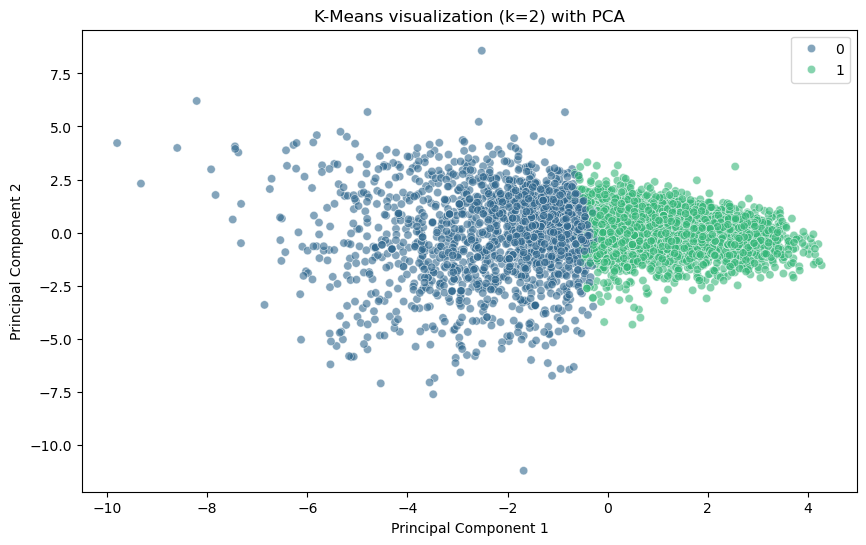

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='viridis', alpha=0.6)
plt.title(f'K-Means visualization (k={optimal_k}) with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [43]:
import numpy as np
import pandas as pd

# STEP 1: Identifica outliers su PC1 (asse orizzontale)
# Dal grafico PCA, gli outliers si estendono oltre PC1 > 4
pc1_outliers = X_pca[:, 0] > 4

# STEP 2: Analizza i loadings di PC1 (contributo di ogni feature)
loadings_pc1 = pd.Series(
    pca.components_[0],  # Prima componente principale
    index=X_severity.columns
).abs().sort_values(ascending=False)

print("=== TOP FEATURES CHE INFLUENZANO PC1 ===")
print(loadings_pc1.head(10))

# STEP 3: Confronta valori originali outliers vs normali
outlier_means = X_severity.iloc[pc1_outliers].mean(axis=0)
normal_means = X_severity.iloc[~pc1_outliers].mean(axis=0)

feature_comparison = pd.DataFrame({
    'Feature': X_severity.columns,
    'Loading_PC1': pca.components_[0],
    'Mean_Outliers': outlier_means,
    'Mean_Normal': normal_means,
    'Difference': outlier_means - normal_means
})

feature_comparison['Abs_Difference'] = feature_comparison['Difference'].abs()
feature_comparison = feature_comparison.sort_values('Abs_Difference', ascending=False)

print("\n=== FEATURES CON MAGGIORI DIFFERENZE ===")
print(feature_comparison.head(10))

# STEP 4: Verifica distribuzione della feature più problematica
top_feature = feature_comparison.iloc[0]['Feature']
top_feature_idx = df_severity_clean.columns.get_loc(top_feature)

print(f"\n=== DISTRIBUZIONE {top_feature} ===")
skewness = pd.Series(X_severity.iloc[:, top_feature_idx]).skew()
print(f"Skewness: {skewness:.2f}")

if abs(skewness) > 1:
    print(f"RACCOMANDAZIONE: Applica log1p a {top_feature}")


ValueError: Length of values (22) does not match length of index (23)

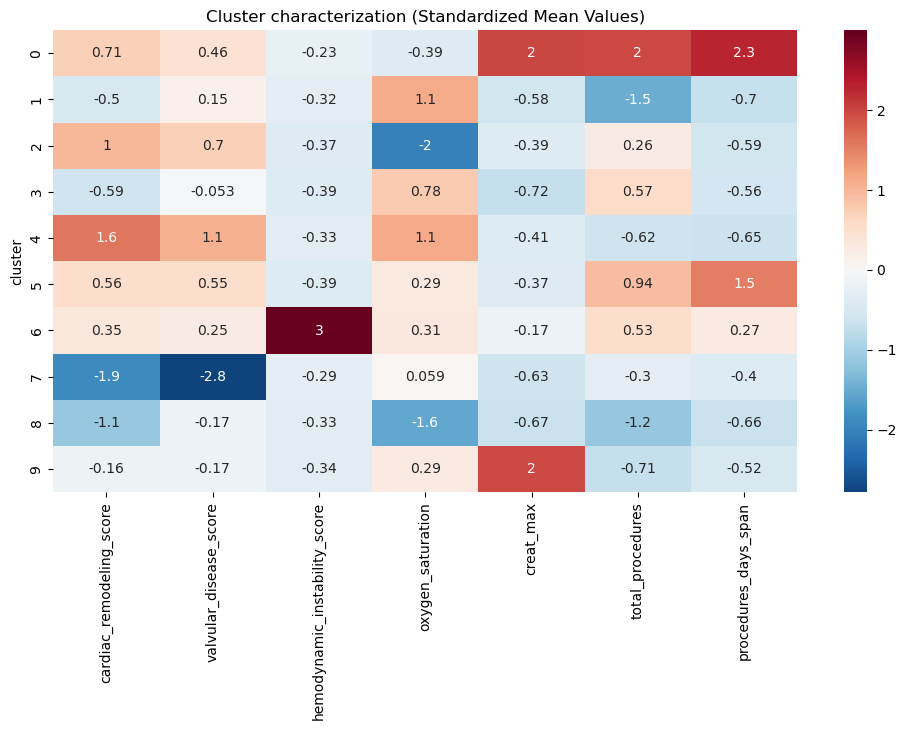

In [ ]:
cluster_means = df_severity_clean.groupby('cluster')[features_severity].mean()
scaler_means = StandardScaler()
cluster_means_scaled = pd.DataFrame(scaler_means.fit_transform(cluster_means), 
                                    columns=features_severity, index=cluster_means.index)

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means_scaled, annot=True, cmap='RdBu_r', center=0)
plt.title('Cluster characterization (Standardized Mean Values)')
plt.show()

In [ ]:
# Ottieni i loadings delle prime due componenti
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features_severity
)

# Ordina per valore assoluto per trovare le feature più influenti
loadings_sorted = loadings.abs().sort_values('PC1', ascending=False)
print(loadings_sorted.head(10))


                                    PC1       PC2
procedures_days_span           0.495735  0.432013
cardiac_remodeling_score       0.478116  0.498007
total_procedures               0.453958  0.425203
valvular_disease_score         0.408765  0.578000
creat_max                      0.330576  0.095243
hemodynamic_instability_score  0.204346  0.148875
oxygen_saturation              0.038037  0.138700


In [ ]:
# Identifica outliers in PC1 e PC2
threshold = 3  # Deviazioni standard
pc1_mean, pc1_std = X_pca[:, 0].mean(), X_pca[:, 0].std()
pc2_mean, pc2_std = X_pca[:, 1].mean(), X_pca[:, 1].std()

outliers_mask = (
    (np.abs(X_pca[:, 0] - pc1_mean) > threshold * pc1_std) |
    (np.abs(X_pca[:, 1] - pc2_mean) > threshold * pc2_std)
)

# Estrai i pazienti outliers
outliers_indices = np.where(outliers_mask)[0]
outliers_data = df_severity_clean.iloc[outliers_indices]


In [ ]:

outliers_stats = X_severity.iloc[outliers_indices].describe()
normal_stats = X_severity.iloc[~outliers_mask].describe()

comparison = pd.DataFrame({
    'outliers_mean': outliers_stats.loc['mean'],
    'normal_mean': normal_stats.loc['mean'],
    'diff': outliers_stats.loc['mean'] - normal_stats.loc['mean']
}).sort_values('diff', key=abs, ascending=False)

print(comparison.head(10))


                               outliers_mean  normal_mean      diff
procedures_days_span                3.078509     0.299769  2.778740
total_procedures                    3.468123     1.073813  2.394310
creat_max                           1.693982     0.910231  0.783752
cardiac_remodeling_score            3.052632     2.389950  0.662681
hemodynamic_instability_score       0.456474     0.067577  0.388897
oxygen_saturation                   1.295123     1.487027 -0.191904
valvular_disease_score              2.077193     2.054000  0.023193


In [ ]:
# Identifica i pazienti outliers più estremi
extreme_outliers = outliers_data.nlargest(10, 'heart_failure_severity_score')

# Analizza il loro profilo completo
print(extreme_outliers[features_severity])

# Controlla se appartengono a un cluster specifico
print(extreme_outliers['cluster'].value_counts())

KeyError: 'heart_failure_severity_score'

## DBSCAN

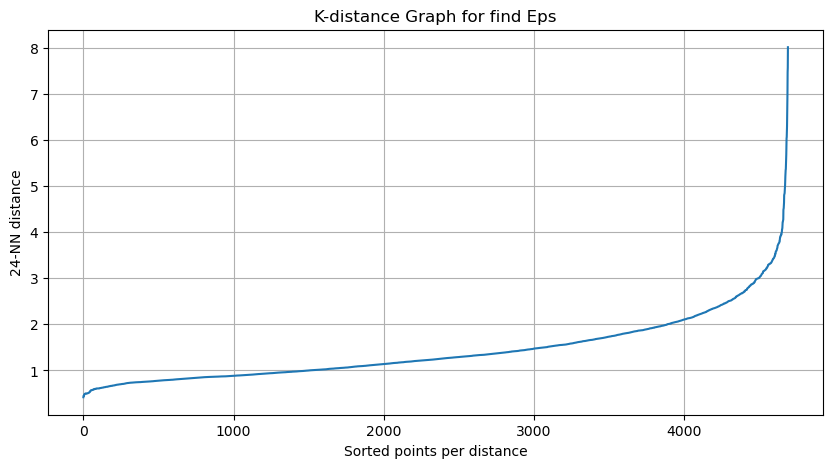

In [ ]:
# Calcolo della distanza k-NN per stimare eps
k = 24 # min_samples ipotetico
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_severity_normalized)
distances, indices = neighbors_fit.kneighbors(X_severity_normalized)

distances = np.sort(distances[:, k-1], axis=0)
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph for find Eps')
plt.xlabel('Sorted points per distance')
plt.ylabel(f'{k}-NN distance')
plt.grid(True)
plt.show()


In [ ]:
# Imposta i parametri in base al grafico sopra
EPSILON = 3.5  # <-- DA TUNARE in base al grafico
MIN_SAMPLES = 24

dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES)
clusters_dbscan = dbscan.fit_predict(X_scaled)

# Statistiche
n_clusters_ = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise_ = list(clusters_dbscan).count(-1)

print(f'Numero di cluster stimati: {n_clusters_}')
print(f'Numero di punti di rumore (outliers): {n_noise_}')

# Visualizzazione PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_dbscan, palette='tab10', alpha=0.6)
plt.title(f'DBSCAN (eps={EPSILON}, min_samples={MIN_SAMPLES})')
plt.show()


NameError: name 'X_scaled' is not defined